# House Price Prediction

## Internship Project – Week 1

### Submitted By:
Palakurthi Venkatesh Goud

### Organization:
XYlofy AI

### Project Objective:
Develop and evaluate machine learning models capable of predicting residential property prices using housing characteristics and amenities.

# Executive Summary

This section will be completed after model development.

It will contain:

- Business Problem
- Best Model
- Key Findings
- Feature Importance
- Business Recommendations

# 1. Business Problem

Real estate pricing is a critical challenge for property buyers, sellers, and developers. Incorrect pricing can lead to financial losses, delayed sales, and poor investment decisions.

This project aims to develop a machine learning model capable of estimating house prices based on property characteristics such as area, bedrooms, bathrooms, stories, parking availability, and other amenities.

The resulting model can support data-driven pricing decisions and improve valuation accuracy.

# 2. Business Objective

The objective of this project is to:

- Analyze housing data
- Identify key factors influencing house prices
- Build predictive machine learning models
- Compare model performance
- Generate actionable business insights

Success will be measured using:

- MAE
- RMSE
- R² Score

# 3. Dataset Overview

Dataset Name:
Housing Prices Dataset

Source:
Kaggle

Records:
545 Houses

Features:
13 Variables

Target Variable:
Price

The dataset contains information about property size, location characteristics, amenities, and furnishing status that may influence house prices.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 4. Dataset Understanding

Before building machine learning models, it is important to understand the structure, quality, and characteristics of the dataset.

This section evaluates:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Statistical summary

In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


### Observation

The dataset contains 545 records and 13 variables, providing a sufficient sample size for building and evaluating machine learning models.

### Business Interpretation

Each record represents a residential property with information related to its physical characteristics and amenities. The dataset size is appropriate for exploratory analysis and predictive modeling.

### Recommendation

Proceed with detailed data quality assessment and exploratory analysis before model development.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Observation

The dataset contains 6 numerical features and 7 categorical features. All 545 records are complete across every column.

### Business Interpretation

The presence of both numerical and categorical variables suggests that house prices are influenced by a combination of measurable property characteristics and qualitative amenities.

Examples:

* Numerical: Area, Bedrooms, Bathrooms
* Categorical: Main Road Access, Air Conditioning, Furnishing Status

### Recommendation

Categorical variables must be converted into machine-learning-friendly numerical representations before model training.


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Observation

No missing values were detected in any column of the dataset.

### Business Interpretation

Data completeness is excellent. Missing values often introduce bias and require imputation strategies. Since no missing values exist, the dataset is immediately suitable for analysis.

### Recommendation

No missing value treatment is required. This allows the project to focus on feature relationships and model optimization.


In [5]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were identified in the dataset.

### Business Interpretation

Each record represents a unique property listing, ensuring that the dataset is free from repeated observations that could bias machine learning models.

### Recommendation

No duplicate removal is required. The dataset can be used directly for further analysis.

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observation

The average house price is approximately 4.77 million, with prices ranging from 1.75 million to 13.30 million.

The average property area is approximately 5,151 square feet, with a maximum size of 16,200 square feet.

Most houses contain:

* 3 Bedrooms
* 1–2 Bathrooms
* 1–2 Stories

### Business Interpretation

The large difference between minimum and maximum values indicates a diverse housing market containing both affordable and premium properties.

The wide spread in area and price suggests that property size may be a major determinant of housing value.

### Recommendation

Area, bathrooms, stories, and parking should be investigated further during exploratory data analysis because they are likely to influence house prices significantly.


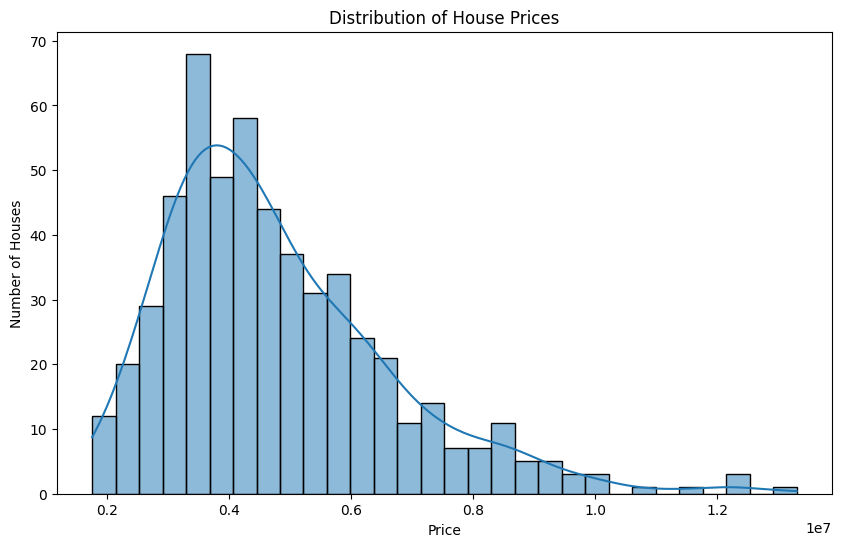

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')

plt.savefig('charts/price_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation

The distribution of house prices is positively skewed (right-skewed). Most properties are concentrated between approximately 3 million and 6 million, while a smaller number of premium properties extend beyond 10 million.

### Business Interpretation

The housing market represented in this dataset is dominated by mid-range properties. High-value luxury properties exist but form only a small segment of the overall market.

### Recommendation

Special attention should be paid to premium-priced properties during model evaluation because they may behave differently from typical houses and can significantly influence prediction errors.


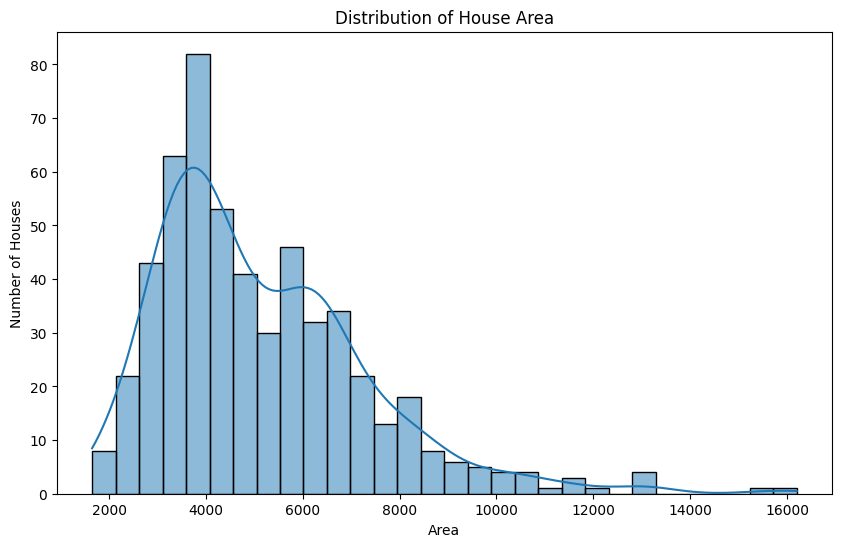

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['area'], bins=30, kde=True)

plt.title('Distribution of House Area')
plt.xlabel('Area')
plt.ylabel('Number of Houses')

plt.savefig('charts/area_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation

Most properties have an area between 3,000 and 7,000 square feet. A small number of properties exceed 10,000 square feet, creating a long right tail in the distribution.

### Business Interpretation

The dataset contains both standard residential properties and a limited number of exceptionally large houses. These larger properties may represent premium market segments.

### Recommendation

Potential outliers should be monitored during model development because extremely large properties can influence regression performance and prediction accuracy.


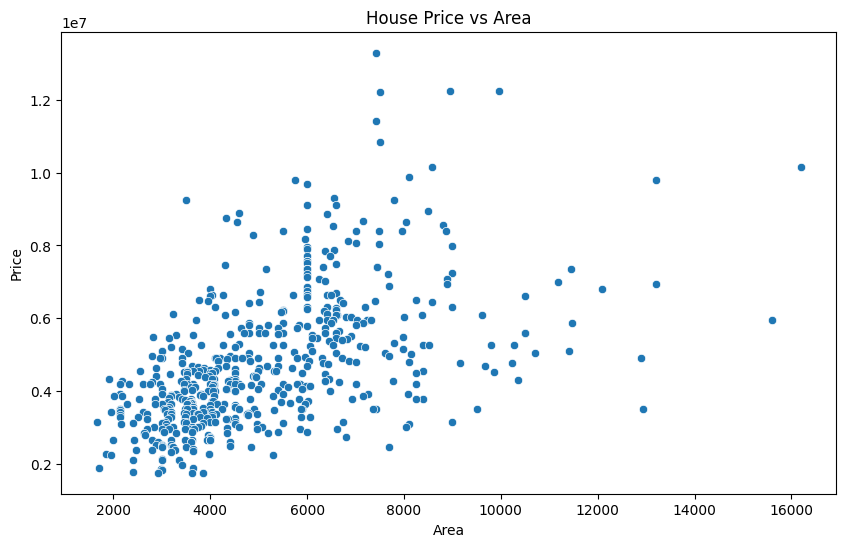

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='area', y='price', data=df)

plt.title('House Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')

plt.savefig('charts/price_vs_area.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation

A clear positive relationship exists between house area and house price. As property area increases, house prices generally increase as well.

However, properties with similar areas sometimes have noticeably different prices, suggesting that additional factors also influence property value.

### Business Interpretation

Area appears to be one of the strongest determinants of house price. Nevertheless, factors such as bathrooms, stories, parking availability, furnishing status, and preferred location also contribute to pricing decisions.

### Recommendation

Area should be expected to emerge as a highly influential feature during feature importance analysis. Additional variables must be incorporated to achieve accurate price predictions.


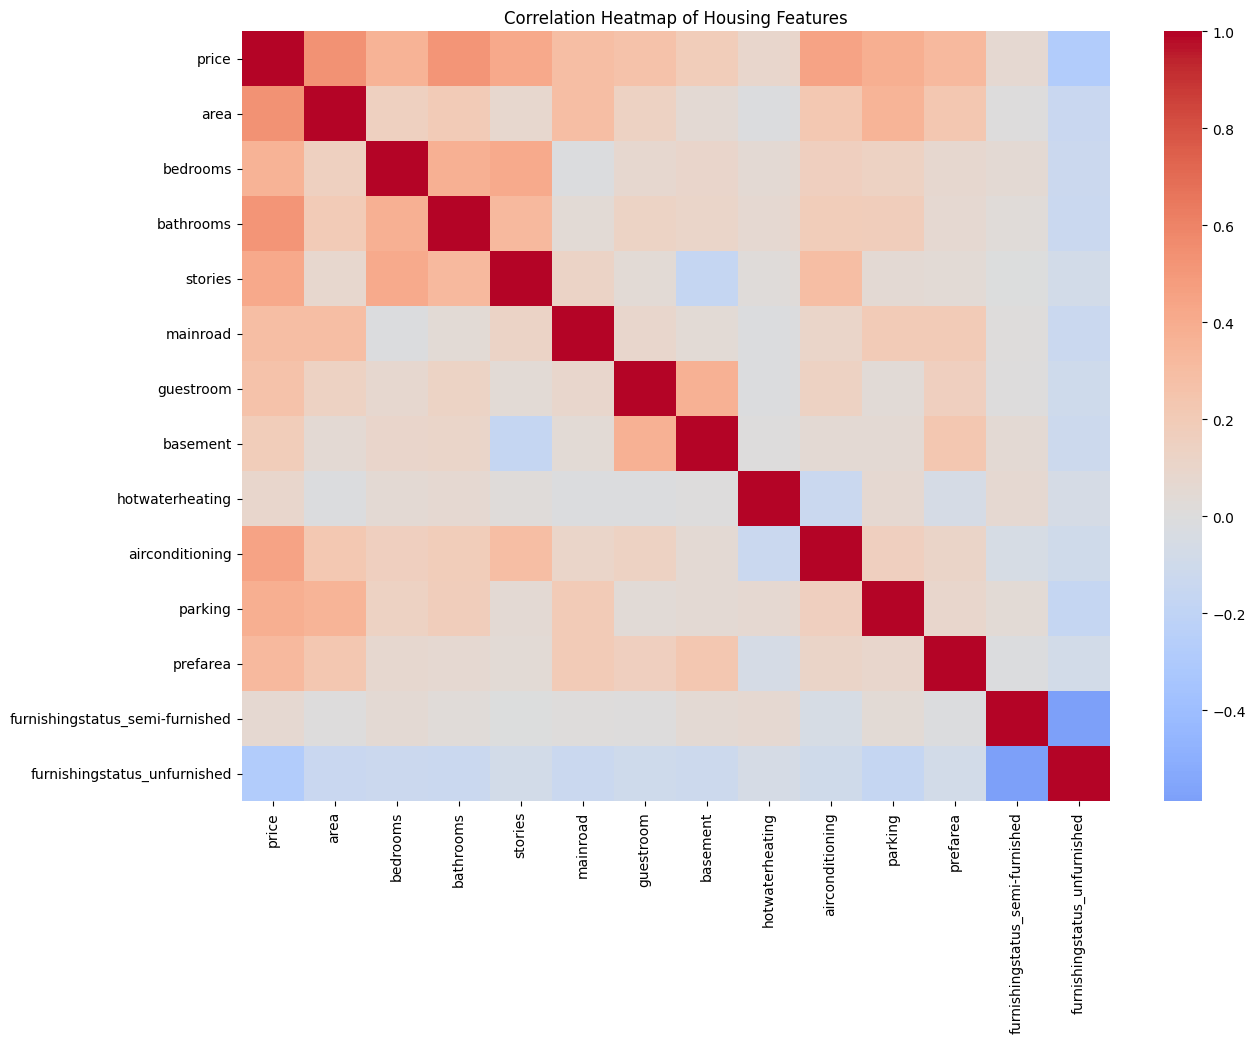

In [13]:
df_corr = df.copy()

binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

df_corr = pd.get_dummies(
    df_corr,
    columns=['furnishingstatus'],
    drop_first=True
)

plt.figure(figsize=(14,10))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Housing Features')

plt.savefig(
    'charts/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

The correlation heatmap reveals that area and bathrooms exhibit the strongest positive relationships with house price. Features such as air conditioning, preferred area, parking availability, and number of stories also show meaningful positive correlations with price.

Certain features demonstrate moderate relationships with one another, indicating the presence of multicollinearity within the dataset.

### Business Interpretation

House prices are influenced by a combination of physical property characteristics and lifestyle-related amenities. Larger houses with more bathrooms, parking spaces, and premium facilities tend to command higher market values.

The existence of correlated predictors suggests that pricing decisions are driven by multiple interconnected factors rather than a single feature.

### Recommendation

Tree-based machine learning models such as Random Forest and Gradient Boosting should be evaluated alongside Linear Regression because they are better equipped to handle complex feature interactions and multicollinearity.

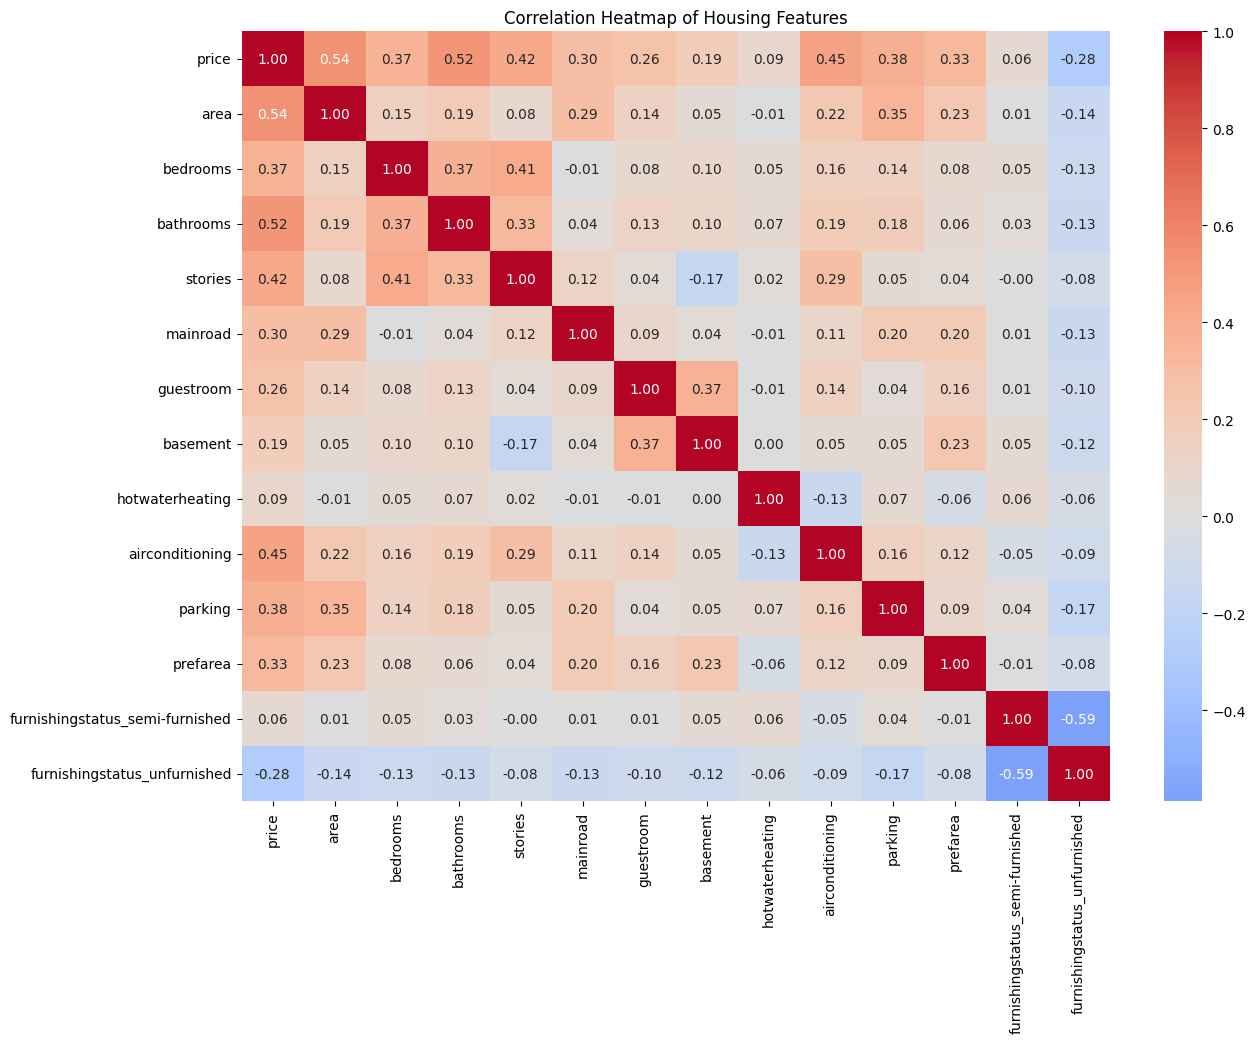

In [14]:
plt.figure(figsize=(14,10))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Housing Features')

plt.savefig(
    'charts/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Area (0.54) and bathrooms (0.52) exhibit the strongest positive correlations with house price. Air conditioning (0.45), stories (0.42), parking (0.38), and bedrooms (0.37) also show meaningful positive relationships.

The furnishing status variable demonstrates a negative relationship with price, indicating that unfurnished properties generally command lower market values.

### Business Interpretation

Property size and functionality appear to be the primary drivers of housing value. Buyers are willing to pay premiums for larger homes, additional bathrooms, modern amenities, and convenient parking facilities.

### Recommendation

Models should prioritize these influential features during prediction. Real estate developers should focus on property size, bathrooms, parking capacity, and comfort-oriented amenities to maximize property value.

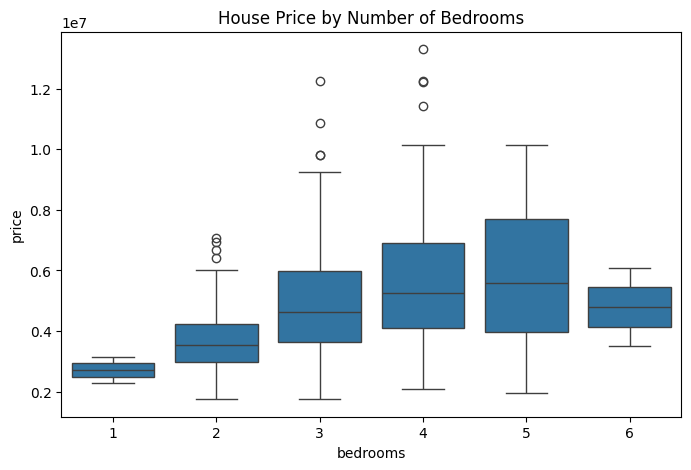

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('House Price by Number of Bedrooms')
plt.savefig('charts/price_vs_bedrooms.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

House prices generally increase as the number of bedrooms increases. However, the relationship is not perfectly linear, as some properties with fewer bedrooms outperform larger houses in terms of price.

### Business Interpretation

While bedroom count contributes to property value, buyers consider multiple factors beyond bedroom quantity. Property size, location, amenities, and overall quality also influence pricing decisions.

### Recommendation

Bedroom count should not be used as a standalone predictor. It should be analyzed together with other housing characteristics to improve prediction accuracy.

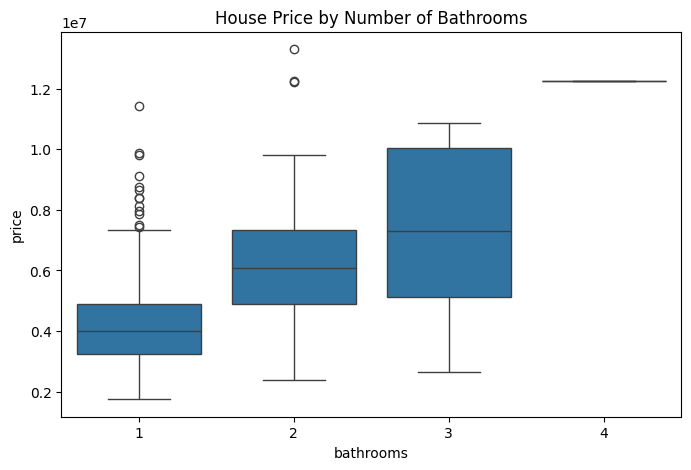

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bathrooms', y='price', data=df)

plt.title('House Price by Number of Bathrooms')

plt.savefig(
    'charts/price_vs_bathrooms.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

House prices increase significantly as the number of bathrooms increases. Properties with 3 and 4 bathrooms generally command substantially higher prices compared to houses with only 1 bathroom.

### Business Interpretation

Bathrooms appear to be a major contributor to property value. Buyers are willing to pay a premium for additional convenience and functionality within a home.

### Recommendation

Developers targeting higher-value market segments should prioritize increasing bathroom availability in residential projects.

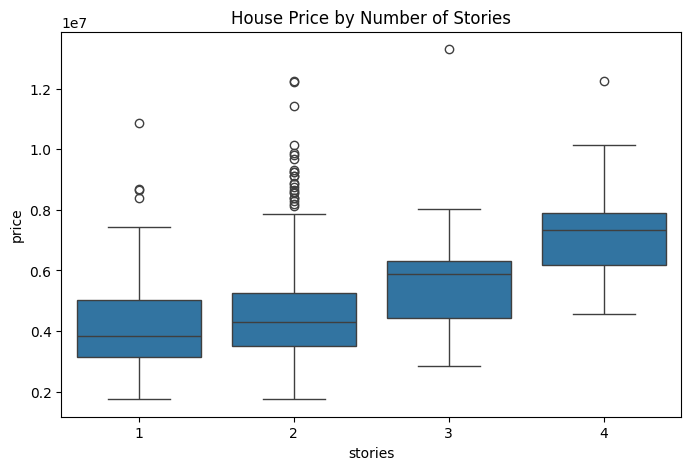

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stories', y='price', data=df)

plt.title('House Price by Number of Stories')

plt.savefig(
    'charts/price_vs_stories.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

A clear upward trend exists between the number of stories and house price. Properties with 4 stories exhibit the highest median prices, while single-story houses generally occupy lower price ranges.

### Business Interpretation

Multi-story homes are perceived as larger and more valuable properties. Additional stories increase usable living space and often indicate premium residential developments.

### Recommendation

The number of stories should be considered an important pricing factor during model development and property valuation.

# 5. Key Insights from Exploratory Data Analysis

## Insight 1: Property size is a major driver of house price.

The scatter plot analysis revealed a strong positive relationship between area and price, indicating that larger properties generally command higher market values.

## Insight 2: Bathrooms significantly influence property value.

Properties with more bathrooms consistently exhibited higher price ranges, suggesting strong buyer preference for additional convenience.

## Insight 3: Multi-story properties command premium prices.

The number of stories demonstrated a positive relationship with house price, indicating that vertical living space contributes to property valuation.

## Insight 4: Air conditioning, parking, and preferred area contribute meaningfully to pricing.

These features showed moderate positive correlations and may improve predictive model performance.

## Insight 5: House prices are influenced by multiple interacting factors.

No single feature fully explains housing prices, validating the use of machine learning models capable of capturing complex relationships.

# 6. Data Preprocessing

Before model development, categorical variables must be converted into numerical representations that machine learning algorithms can understand.

This phase includes:

- Feature encoding
- Dataset preparation
- Feature-target separation
- Training and testing split

In [19]:
df_model = df.copy()

df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [20]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_model[col] = df_model[col].map({
        'yes': 1,
        'no': 0
    })

In [21]:
df_model = pd.get_dummies(
    df_model,
    columns=['furnishingstatus'],
    drop_first=True
)

In [22]:
df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [23]:
X = df_model.drop('price', axis=1)
y = df_model['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (436, 13)
Testing Set: (109, 13)


### Observation

The dataset was split into training and testing subsets using an 80:20 ratio.

### Business Interpretation

The training dataset is used to learn relationships between housing features and property prices, while the testing dataset evaluates how well the model performs on unseen properties.

### Recommendation

Maintaining a separate testing dataset ensures that model performance reflects real-world predictive capability rather than memorization of historical data.

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             545 non-null    int64
 1   bedrooms                         545 non-null    int64
 2   bathrooms                        545 non-null    int64
 3   stories                          545 non-null    int64
 4   mainroad                         545 non-null    int64
 5   guestroom                        545 non-null    int64
 6   basement                         545 non-null    int64
 7   hotwaterheating                  545 non-null    int64
 8   airconditioning                  545 non-null    int64
 9   parking                          545 non-null    int64
 10  prefarea                         545 non-null    int64
 11  furnishingstatus_semi-furnished  545 non-null    bool 
 12  furnishingstatus_unfurnished     545 non-null    b

### Observation

All categorical variables were successfully converted into numerical representations. The final feature matrix contains 13 predictor variables and no remaining text-based columns.

### Business Interpretation

The dataset is now machine-learning compatible, allowing predictive algorithms to identify relationships between property characteristics and house prices.

### Recommendation

The prepared dataset can now be used to train and evaluate multiple regression models for house price prediction.

# 7. Model Development

Three machine learning models will be developed and compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

The objective is to identify the model that provides the most accurate and reliable house price predictions.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Results
MAE: 970043.4039201641
RMSE: 1324506.9600914388
R²: 0.6529242642153184


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 1014947.3230122325
RMSE: 1399769.443949671
R²: 0.6123598247296523


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting Results
MAE: 945252.9979819461
RMSE: 1287074.1795790703
R²: 0.6722649279763833


In [29]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,9.452530e+05,1.287074e+06,0.672265
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


# 8. Model Evaluation and Comparison

Three machine learning models were trained and evaluated for house price prediction.

The models were assessed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

A higher R² score and lower MAE/RMSE indicate better predictive performance.

### Observation

Among the three evaluated models, Gradient Boosting Regressor achieved the highest R² Score (0.6723) and the lowest prediction errors.

Linear Regression performed competitively and achieved an R² Score of 0.6529.

Random Forest Regressor produced the lowest performance among the evaluated models.

### Business Interpretation

The results suggest that house prices are influenced by both linear and moderately complex relationships among housing features.

Gradient Boosting successfully captured these relationships while maintaining strong generalization performance on unseen data.

### Recommendation

Gradient Boosting Regressor is selected as the final model for this project due to its superior predictive accuracy and robustness.

Although Random Forest is generally considered a powerful ensemble algorithm, it did not outperform Gradient Boosting in this dataset.

This demonstrates the importance of model comparison rather than assuming that a more complex model will automatically achieve superior performance.

The findings highlight that model suitability depends on the characteristics of the dataset rather than model popularity.

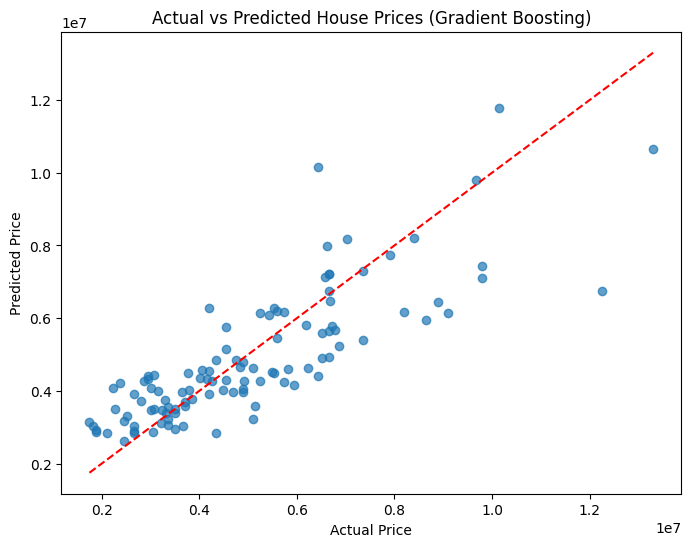

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    gb_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Gradient Boosting)')

plt.savefig(
    'charts/actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,area,0.461708
2,bathrooms,0.172952
8,airconditioning,0.094350
9,parking,0.048156
1,bedrooms,0.045724
3,stories,0.042845
6,basement,0.031567
12,furnishingstatus_unfurnished,0.028457
10,prefarea,0.025426
7,hotwaterheating,0.016442


# 9. Feature Importance Analysis

The Gradient Boosting Regressor was selected as the final model and used to identify the relative importance of each feature in predicting house prices.

Feature importance scores indicate how much each variable contributes to the model's prediction process.

### Observation

Area emerged as the most influential feature, contributing approximately 46% of the model's predictive capability.

Bathrooms ranked as the second most important feature with approximately 17% importance.

Air conditioning, parking availability, bedrooms, and stories also contributed meaningfully to house price prediction.

### Business Interpretation

Property size is the primary driver of house value within this dataset. Buyers place significant importance on living space, while additional bathrooms and modern amenities further increase market value.

The findings indicate that both structural characteristics and lifestyle-related amenities influence residential property pricing.

### Recommendation

Developers seeking to maximize property value should prioritize larger floor plans, adequate bathroom facilities, air conditioning, and sufficient parking capacity.

### Observation

Most predicted values are concentrated near the ideal prediction line, indicating that the model successfully captures the underlying relationship between housing features and property prices.

Some deviations are visible among high-value properties, suggesting greater prediction difficulty within the luxury housing segment.

### Business Interpretation

The model performs well for the majority of residential properties and demonstrates reasonable generalization capability on unseen data.

Prediction errors are more pronounced among premium properties due to their unique characteristics and lower representation within the dataset.

### Recommendation

Additional premium property data may further improve model accuracy for high-value housing segments.

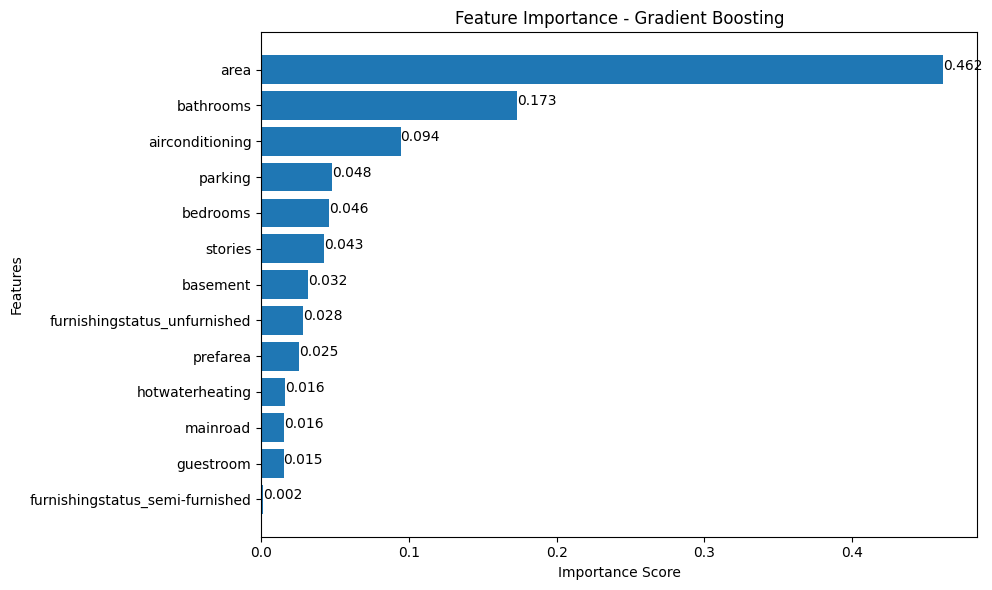

In [34]:
plt.figure(figsize=(10,6))

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance Score')
plt.ylabel('Features')

for index, value in enumerate(feature_importance['Importance']):
    plt.text(
        value,
        index,
        f'{value:.3f}'
    )

plt.tight_layout()

plt.savefig(
    'charts/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

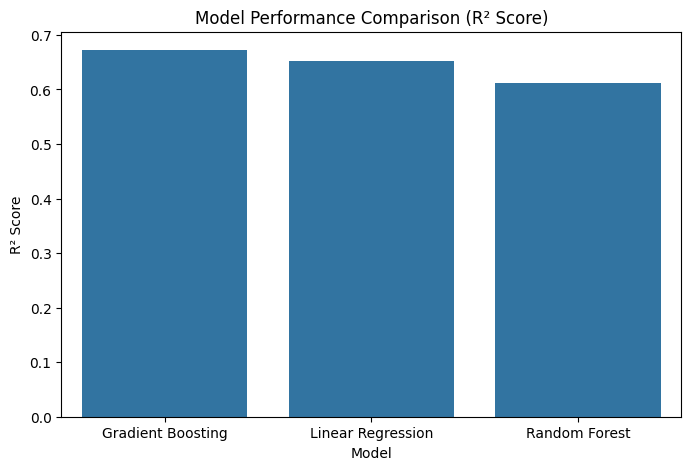

In [35]:
comparison_chart = results.sort_values(
    by='R2 Score',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison_chart
)

plt.title('Model Performance Comparison (R² Score)')
plt.ylabel('R² Score')

plt.savefig(
    'charts/model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 10. Executive Summary

## Objective

The objective of this project was to develop a machine learning model capable of predicting residential property prices based on housing characteristics and amenities.

## Best Performing Model

Gradient Boosting Regressor

R² Score: 0.6723

MAE: 945,253

RMSE: 1,287,074

## Key Findings

- Area was the strongest predictor of house price.
- Bathrooms significantly influenced market value.
- Air conditioning emerged as an important pricing factor.
- Parking availability contributed positively to property value.
- House prices are influenced by a combination of structural and lifestyle-related features.

## Business Impact

The developed model can support property valuation, pricing decisions, and real estate market analysis by providing data-driven price estimates.

# 11. Business Recommendations

1. Prioritize larger floor plans when developing residential properties.

2. Increase bathroom availability in premium housing projects.

3. Include modern comfort amenities such as air conditioning.

4. Provide adequate parking facilities to improve market value.

5. Use predictive analytics models to support property valuation and pricing decisions.

6. Focus development efforts in preferred residential areas where higher pricing potential exists.

# 13. Project Conclusion

This project successfully developed and evaluated multiple machine learning models for house price prediction using residential property characteristics.

After comparing Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor, the Gradient Boosting model achieved the best predictive performance with an R² Score of 0.6723.

The analysis revealed that property area, number of bathrooms, air conditioning, parking availability, and bedrooms are the most influential factors affecting house prices.

The results demonstrate that machine learning can support data-driven real estate valuation and assist buyers, sellers, and developers in making informed pricing decisions.

# 14. Future Improvements

The current project can be enhanced through:

- Collection of larger housing datasets
- Inclusion of geographic location coordinates
- Integration of market trend indicators
- Hyperparameter optimization using Grid Search
- Advanced ensemble techniques such as XGBoost and LightGBM

These improvements may further increase predictive accuracy and real-world applicability.